In [4]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
from statsmodels.formula.api import ols
# 상관분석을 위한 참조
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

In [11]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지


In [12]:
origin = load_data('cars')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab12_/cars.xlsx
[desc] 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)

field    description
-------  -------------
speed    속도
dist     제동거리


===== 데이터 크기 확인 =====
데이터셋 크기: (50, 2)
열 개수: 2
행 개수: 50

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


📘 #03. 탐색적 데이터 분석

📝 1. 두 변수간의 관계 시각화

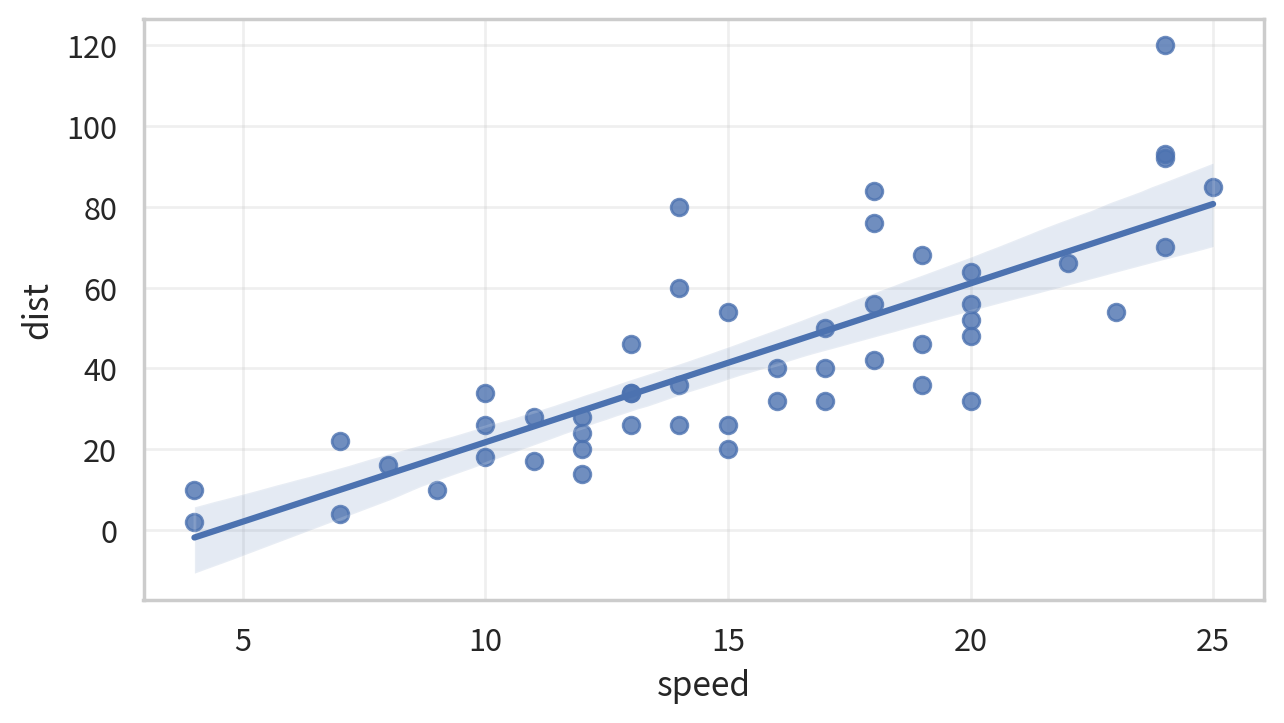

자동차 속도와 제동거리는 선형성을 충족하고 양의 상관관계가 있는것으로 보인다.


In [14]:
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) BoxPlot 그리기
sb.regplot(data=origin, x='speed', y='dist')
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료
print(f"자동차 속도와 제동거리는 선형성을 충족하고 양의 상관관계가 있는것으로 보인다.")

📘 #04. 추론통계

📝 1. 상관분석


=== 이상치 확인 ===
이상치 존재


,original_skew,log_skew,outliers(|z|>3)
speed,-0.117510,-1.668586,0.0
dist,0.806895,-1.384501,1.0


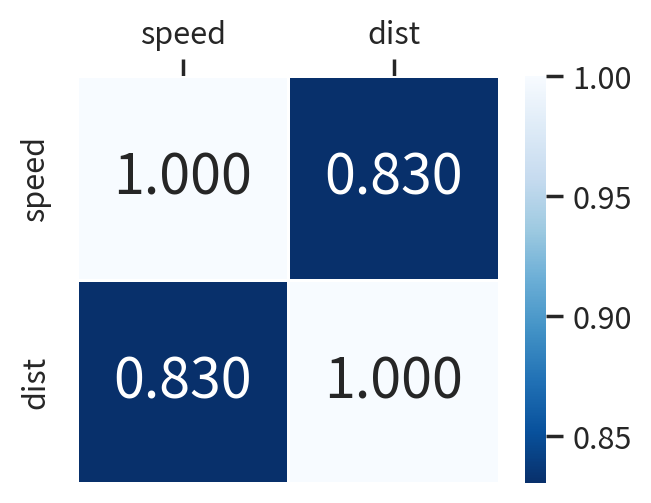

본 분석에서는 speed과 dist 간 상관관계를 검토하였다.

데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.

분석 결과, 스피어만 상관계수는 r = 0.830, p = 0.000 (으)로 나타나 두 변수 간 양의 단조 관계가 존재함을 확인하였다.


In [18]:
xname = 'speed'
yname = 'dist'

# ---------------------------------
# 선형성 가정 확인 -> 산점도 그래프를 통해 시각적으로 확인
# ---------------------------------
linearity_ok = True  # 선형성 적합 여부 (True=적합, False=부적합)

# ---------------------------------
# 이상치와 왜도 검정
# ---------------------------------
data = origin[[xname, yname]]
results = {}

for col in data.columns:
    temp = data[col].dropna()

    # 왜도 계산
    skew_original = temp.skew()

    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))

    # 로그 변환 후 왜도 계산
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()

    results[col] = {
        'original_skew': skew_original,
        'log_skew': skew_log,
        'outliers(|z|>3)': outlier_count
    }

results_df = DataFrame(results).T

# 이상치 점검 결과
outlier_flag = len(results_df[results_df['outliers(|z|>3)'] > 0]) > 0

print("\n=== 이상치 확인 ===")
print("이상치 존재" if outlier_flag else "이상치 존재하지 않음")
display(results_df)

# ---------------------------------
# 상관분석
# ---------------------------------
report = f"본 분석에서는 {xname}과 {yname} 간 상관관계를 검토하였다.\n\n"

# 1. 상관계수 선택
if linearity_ok and not outlier_flag:
    chosen = 'pearson'
    corr, pval = pearsonr(origin[xname], origin[yname])

    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        report += (
            "데이터 점검 결과, 두 변수의 관계는 선형적이며 이상치의 영향도 크지 않아 "
            "피어슨 상관계수를 사용하였다.\n\n"
            f"분석 결과, 피어슨 상관계수는 r = {corr:0.3f}, p = {pval:0.3f} (으)로 나타나 "
            f"두 변수 간 {'양의 상관' if corr > 0 else '음의 상관'} 관계가 통계적으로 유의함을 확인하였다."
        )

else:
    chosen = 'spearman'
    corr, pval = spearmanr(origin[xname], origin[yname])

    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        report += (
            "데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 "
            "스피어만 상관계수를 사용하였다.\n\n"
            f"분석 결과, 스피어만 상관계수는 r = {corr:0.3f}, p = {pval:0.3f} (으)로 나타나 "
            f"두 변수 간 {'양의 단조' if corr > 0 else '음의 단조'} 관계가 존재함을 확인하였다."
        )

# ---------------------------------
# 결과 시각화
# ---------------------------------
corr_matrix = origin[[xname, yname]].corr(method=chosen)

# 1) 그래프 초기화
width_px = 650
height_px = 500
rows = 1
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) heatmap 그리기
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidths=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20}
)

# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()

# ---------------------------------
# 결과 보고 출력
# ---------------------------------
print(report)


📝 2. 단순선형회귀

1) 행렬기반 방식

독립변수 행렬 준비

In [19]:
x = origin[["speed"]]
x.head()

,speed
0,4
1,4
2,7
3,7
4,8


종속변수는 Series 형태로 준비 

In [20]:
y = origin["dist"]
y.head()

0     2
1    10
2     4
3    22
4    16
Name: dist, dtype: int64

상수항 추가<br>
y = ax + b 형태가 기본형이므로 b 역할을 하기 위한 상수항을 추가해야 한다.<br>
상수항이 없다면 절편이 0으로 고정된 잘못된 모델이 만들어질 수 있음<br>
회귀선이 데이터 분포에 맞게 조정되지 않음<br>
모델의 적합도가 떨어짐<br>
파라미터 해석도 왜곡됨<br>
대부분의 현실 데이터는 원점을 지나지 않으므로 절편은 필수임.

In [21]:
X = sm.add_constant(x)
X.head()

,const,speed
0,1.0,4
1,1.0,4
2,1.0,7
3,1.0,7
4,1.0,8


회귀분석 수행

In [22]:
# OLS 모델 객체 생성
# -> 이 단계에서는 아직 학습(fit)되지 않은 '모형의 틀'만 만들어짐
model = sm.OLS(y, X)
# 모델 적합(Fit)
# -> 데이터를 이용해 회귀계수(β)를 추정하고, 모델을 완성하는 단계
fit = model.fit()
# 적합된 모델 객체의 분석 결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                   목, 11 12 2025   Prob (F-statistic):           1.49e-12
Time:                        10:39:08   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

2) formula API 방식

In [24]:
# 학습 모델 객체 생성
model = ols("dist ~ speed", data=origin)
# 모델적합
fit = model.fit()
# 분석결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                   목, 11 12 2025   Prob (F-statistic):           1.49e-12
Time:                        10:39:28   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

📘 #05. 분석결과 해석 방법

📝 1. 모형 적합도 해석 (1~6)<br>
상관분석은 단순히 “관계가 있다 / 없다”를 알려주지만, 회귀분석에서는 그 관계를 수식으로 표현하고 모델이 얼마나 좋은 모델인지 평가해야 한다.<br>
모델이 데이터를 잘 설명하고 있는가<br>
예측력이 충분한가<br>
다른 모델보다 더 좋은가<br>
이 모델을 사용할 가치가 있는가<br>

2. 회귀계수 해석 (7~8)<br>
회귀계수는 독립변수가 종속변수에 미치는 영향을 숫자로 표현한 값이며, 기울기는 변화량을, 절편은 직선의 기준점을 의미한다.<br>
1) 절편(β₀)<br>
X = 0일 때 Y의 값<br>
직선의 시작점을 결정<br>
해석보다 모델의 구조를 잡는 역할이 크다.<br>
2) 기울기(β₁, β₂, …)<br>
독립변수가 1 증가할 때 종속변수가 얼마나 변하는지 나타내는 값<br>
회귀분석에서 가장 중요한 부분<br>
독립변수의 영향력을 수치로 보여줌

3) 분석 결과 해석<br>
4) 회귀계수를 수식으로 정리<br>
y = ax + b<br>
종속변수 = ⑧ × 독립변수 + ⑦<br>
즉,<br>
dist = 3.9324 × speed − 17.5791<br>
4. p값 (9)<br>
p-value (유의확률)
<의미><br>
회귀계수가 0(효과 없음)이라는 귀무가설을<br>
검정하는 값.<br>
p ≤ 0.05이면 회귀계수가 유의미하게 0이 아니다, 즉 독립변수가 종속변수에 영향을 준다는 의미.<br>
<dist ~ speed 모형에서의 해석><br>
speed의 p값 = 0.000 → p <0.001 수준에서 매우 유의.
즉, speed는 dist에 통계적으로 유의한<br>
영향을 미친다.

📘 #06. 회귀분석의 결과 보고<br>
📝 1. 모형 적합도 보고<br>
회귀모형이 통계적으로 유의한지 판단하기 위해 F통계량,<br>
자유도(df₁, df₂), p-value, 그리고 설명력(R²)을 함께 보고한다.<br>
보고 템플릿<br>
모형 유의성:<br>
F(⑩, ⑪) = ③, p < 0.05, R² = ①<br>
예시<br>
dist를 종속변수로, speed를 독립변수로 한 단순회귀분석 결과, 모형은 통계적으로<br> 유의하였다.<br>
F(1, 48) = 89.57, p < 0.001, R² = 0.651.<br>
즉, speed는 dist의 약 65.1%를 설명하는 것으로 나타났다.<br>
📝 2. 독립변수 보고<br>
독립변수가 종속변수에 유의미한 영향을 주는지 보고하기 위해<br>
회귀계수(β), t값, 자유도(df), p-value,<br>
(선택적으로 95% 신뢰구간)을 기술한다.<br>
보고 템플릿<br>
독립변수 유의성:<br>
β = ⑦, t(⑪) = ⑫, p < 0.05<br>
예시<br>
speed의 회귀계수는 β = 3.93으로 나타났으며, 이는 dist에 유의미하게 정(+)적<br> 영향을 미쳤다.<br>
t(48) = 9.46, p < 0.001.<br>
즉, speed가 1 증가할 때 dist는 평균적으로 3.93 증가하는 것으로 해석된다.

#07. 실제 데이터와 모형의 예측값 비교

📝 1. 모형 예측값 얻기<br>
분석 모형에 x에 해당하는 speed를 넣어 y에 해당하는 dist가 계산된 값<br>

In [25]:
df = origin.copy()
df['y_pred'] = fit.predict(X)
df.head()

,speed,dist,y_pred
0,4,2,-1.849460
1,4,10,-1.849460
2,7,4,9.947766
3,7,22,9.947766
4,8,16,13.880175


In [26]:
df_melt = df.melt(
id_vars="speed", # speed는 그대로 둠
value_vars=["dist", "y_pred"], # long 형태로 변환할 변수
var_name="variable", # 명목형 변수명
value_name="value" # 값 변수명
)
df_melt.head()

,speed,variable,value
0,4,dist,2.0
1,4,dist,10.0
2,7,dist,4.0
3,7,dist,22.0
4,8,dist,16.0


📝 2. 시각화 비교

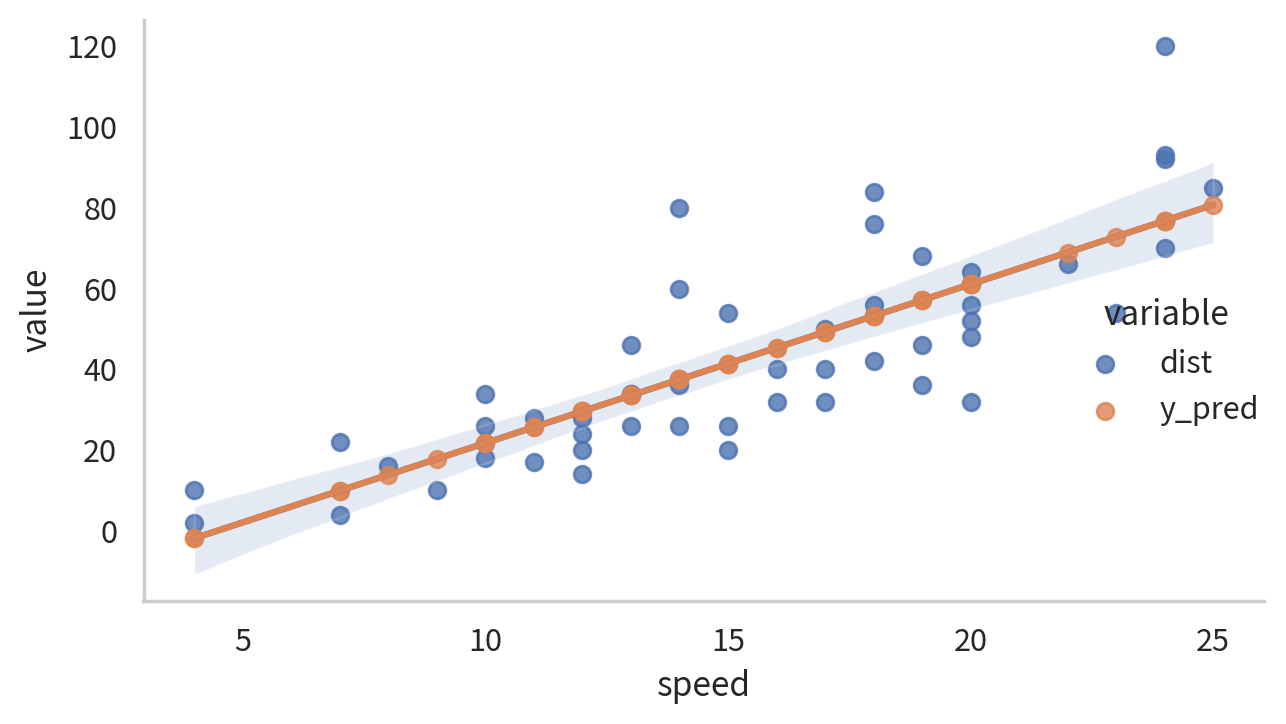

In [28]:
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# 2) LM Plot 그리기
g = sb.lmplot(data=df_melt, x='speed', y='value', hue='variable')
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])
plt.grid()
# 3) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료